# 🔷 STEP 6: VISUALIZATION & DASHBOARD
Comprehensive visualizations for predictive maintenance dashboard

In [0]:
from pyspark.sql.functions import col, lit, expr
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions data
predictions_df = spark.read.table("cmapss_predictions")

print("✅ Prediction data loaded")
print(f"Shape: {predictions_df.count()} rows, {len(predictions_df.columns)} columns")

✅ Prediction data loaded
Shape: 31622 rows, 38 columns


## 📊 VISUALIZATION 1: RUL vs Cycle (Degradation Curve)

In [0]:
# Select sample engines for visualization
sample_engines = [1, 2, 3, 5, 10]

viz_data = predictions_df.filter(col("engine_id").isin(sample_engines))

print(f"📈 RUL Degradation for {len(sample_engines)} Sample Engines")
print("Shows how RUL decreases as cycles progress")

display(viz_data.select("cycle", "RUL", "engine_id"))

📈 RUL Degradation for 5 Sample Engines
Shows how RUL decreases as cycles progress


cycle,RUL,engine_id
9,183,1
12,180,1
14,178,1
22,170,1
24,168,1
25,167,1
26,166,1
28,164,1
31,161,1
35,157,1


## 📊 VISUALIZATION 2: Actual vs Predicted RUL

In [0]:
# Actual vs Predicted scatter plot
print("📈 Model Prediction Accuracy")
print("Points closer to diagonal line indicate better predictions")

# Sample for better visualization
sample_preds = predictions_df.sample(0.1, seed=42)

display(sample_preds.select("RUL", "predicted_RUL"))

# Calculate prediction error
error_df = predictions_df.withColumn("error", expr("abs(RUL - predicted_RUL)"))
avg_error = error_df.select("error").agg({"error": "avg"}).collect()[0][0]
print(f"\n✅ Average Prediction Error: {avg_error:.2f} cycles")

📈 Model Prediction Accuracy
Points closer to diagonal line indicate better predictions


RUL,predicted_RUL
25,54.30372910654858
19,29.967243446406425
61,136.2965318171937
58,145.62680046290436
20,67.52241441677761
208,178.01240285103978
190,163.14199128347417
114,138.22007805842404
40,41.85582816389615
0,12.643402491458481



✅ Average Prediction Error: 37.24 cycles


## 📊 VISUALIZATION 3: Sensor Degradation Trends

In [0]:
# Sensor degradation for a single engine
engine_1 = predictions_df.filter(col("engine_id") == 1)

print("📈 Sensor Values Over Engine Lifetime (Engine #1)")
print("Observe how sensors change as engine degrades")

# Select key sensors to visualize
display(engine_1.select("cycle", "s2", "s3", "s4", "s7", "s11"))

📈 Sensor Values Over Engine Lifetime (Engine #1)
Observe how sensors change as engine degrades


cycle,s2,s3,s4,s7,s11
9,642.12,1590.98,1394.8,553.69,47.29
12,642.06,1583.41,1400.15,554.52,47.18
14,642.35,1592.95,1399.16,554.48,47.44
22,642.77,1592.93,1400.57,553.63,47.24
24,642.38,1590.83,1398.81,553.49,47.44
25,642.77,1594.1,1399.39,554.0,47.36
26,642.16,1589.08,1396.07,554.11,47.26
28,642.35,1582.84,1399.13,554.68,47.41
31,642.02,1584.18,1396.9,554.13,47.41
35,642.44,1590.0,1403.0,554.3,47.31


## 📊 VISUALIZATION 4: PCA Component Visualization

In [0]:
# PCA visualization colored by RUL
print("📈 PCA Components (PC1 vs PC2)")
print("Color gradient shows RUL: Red = Low RUL (failing), Blue = High RUL (healthy)")

sample_pca = predictions_df.sample(0.05, seed=42)
display(sample_pca.select("PC1", "PC2", "RUL"))

📈 PCA Components (PC1 vs PC2)
Color gradient shows RUL: Red = Low RUL (failing), Blue = High RUL (healthy)


PC1,PC2,RUL
0.14628603,-0.7225899,61
3.3913162,-1.9719764,40
3.9149747,-2.5553305,0
-1.4661285,-0.34236804,172
0.09625953,-0.8100834,210
-4.576458,0.64783716,143
0.058242816,-0.80758756,96
0.091934964,-0.73429686,19
7.588163,4.511879,205
3.4621706,-1.9057525,182


## 📊 VISUALIZATION 5: Health Clusters

In [0]:
from pyspark.sql.functions import mean, count

# Cluster distribution
print("📈 Engine Health Clusters")
print("Cluster 0, 1, 2 represent different health states")

display(predictions_df.select("PC1", "PC2", "cluster"))

# Show cluster statistics
print("\n📊 Cluster Statistics:")
predictions_df.groupBy("cluster").agg(
    mean("RUL").alias("avg_RUL"),
    count("*").alias("count")
).orderBy("cluster").show()

📈 Engine Health Clusters
Cluster 0, 1, 2 represent different health states


PC1,PC2,cluster
4.113054,-2.38416,1
-4.603006,0.7061826,0
-4.5885816,0.71346253,0
0.048759956,-0.73595923,1
0.14628603,-0.7225899,1
0.08804159,-0.74333775,1
0.12236957,-0.7433322,1
-1.5249293,-0.38242787,0
4.1342487,-2.35171,1
-1.5264441,-0.40157905,0



📊 Cluster Statistics:
+-------+------------------+-----+
|cluster|           avg_RUL|count|
+-------+------------------+-----+
|      0|122.88462025316456|15800|
|      1| 122.1902505621587|12452|
|      2|120.85548961424333| 3370|
+-------+------------------+-----+



## 📊 VISUALIZATION 6: RUL Distribution by Cluster

In [0]:
# Box plot: RUL distribution by cluster
print("📈 RUL Distribution Across Health Clusters")

display(predictions_df.select("cluster", "RUL"))

print("\nInterpretation:")
print("* High RUL cluster → Healthy engines")
print("* Low RUL cluster → Critical engines needing maintenance")

📈 RUL Distribution Across Health Clusters


cluster,RUL
1,25
0,20
0,19
1,1
1,61
1,59
1,58
0,50
1,48
0,47



Interpretation:
* High RUL cluster → Healthy engines
* Low RUL cluster → Critical engines needing maintenance


## 📊 VISUALIZATION 7: Prediction Error Distribution

In [0]:
# Prediction error histogram
error_df = predictions_df.withColumn(
    "prediction_error", 
    expr("predicted_RUL - RUL")
)

print("📈 Prediction Error Distribution")
print("Centered around 0 indicates unbiased predictions")

display(error_df.select("prediction_error"))

# Error statistics
print("\n📊 Error Statistics:")
error_df.select("prediction_error").describe().show()

📈 Prediction Error Distribution
Centered around 0 indicates unbiased predictions


prediction_error
29.30372910654858
2.3590531841488094
10.967243446406425
15.38223536610354
75.29653181719371
77.65516224613435
87.62680046290436
71.59714869122983
74.22425849286114
5.349570313432025



📊 Error Statistics:
+-------+-------------------+
|summary|   prediction_error|
+-------+-------------------+
|  count|              31622|
|   mean|-0.3197118531424526|
| stddev|  52.45664741800682|
|    min|-383.69730435132425|
|    max|  198.5720097770938|
+-------+-------------------+



## 📊 VISUALIZATION 8: Dataset Comparison

In [0]:
# Performance by dataset
print("📈 Model Performance Across Datasets (FD001-FD004)")

dataset_perf = error_df.groupBy("dataset").agg(
    mean(expr("abs(prediction_error)")).alias("MAE"),
    mean("RUL").alias("avg_RUL"),
    count("*").alias("samples")
).orderBy("dataset")

display(dataset_perf)

print("\n📋 Dataset Characteristics Recap:")
print("FD001: Single condition, single fault")
print("FD002: Multiple conditions, single fault")
print("FD003: Single condition, multiple faults")
print("FD004: Multiple conditions, multiple faults (most challenging)")

📈 Model Performance Across Datasets (FD001-FD004)


dataset,MAE,avg_RUL,samples
FD001,30.282190094095824,108.38376655223149,4078
FD002,33.21715485125237,108.5062044141328,10557
FD003,40.56524539896953,137.3210332103321,4878
FD004,41.762669966639265,133.20934841853168,12109



📋 Dataset Characteristics Recap:
FD001: Single condition, single fault
FD002: Multiple conditions, single fault
FD003: Single condition, multiple faults
FD004: Multiple conditions, multiple faults (most challenging)


## 📊 VISUALIZATION 9: Matplotlib/Seaborn Advanced Plots

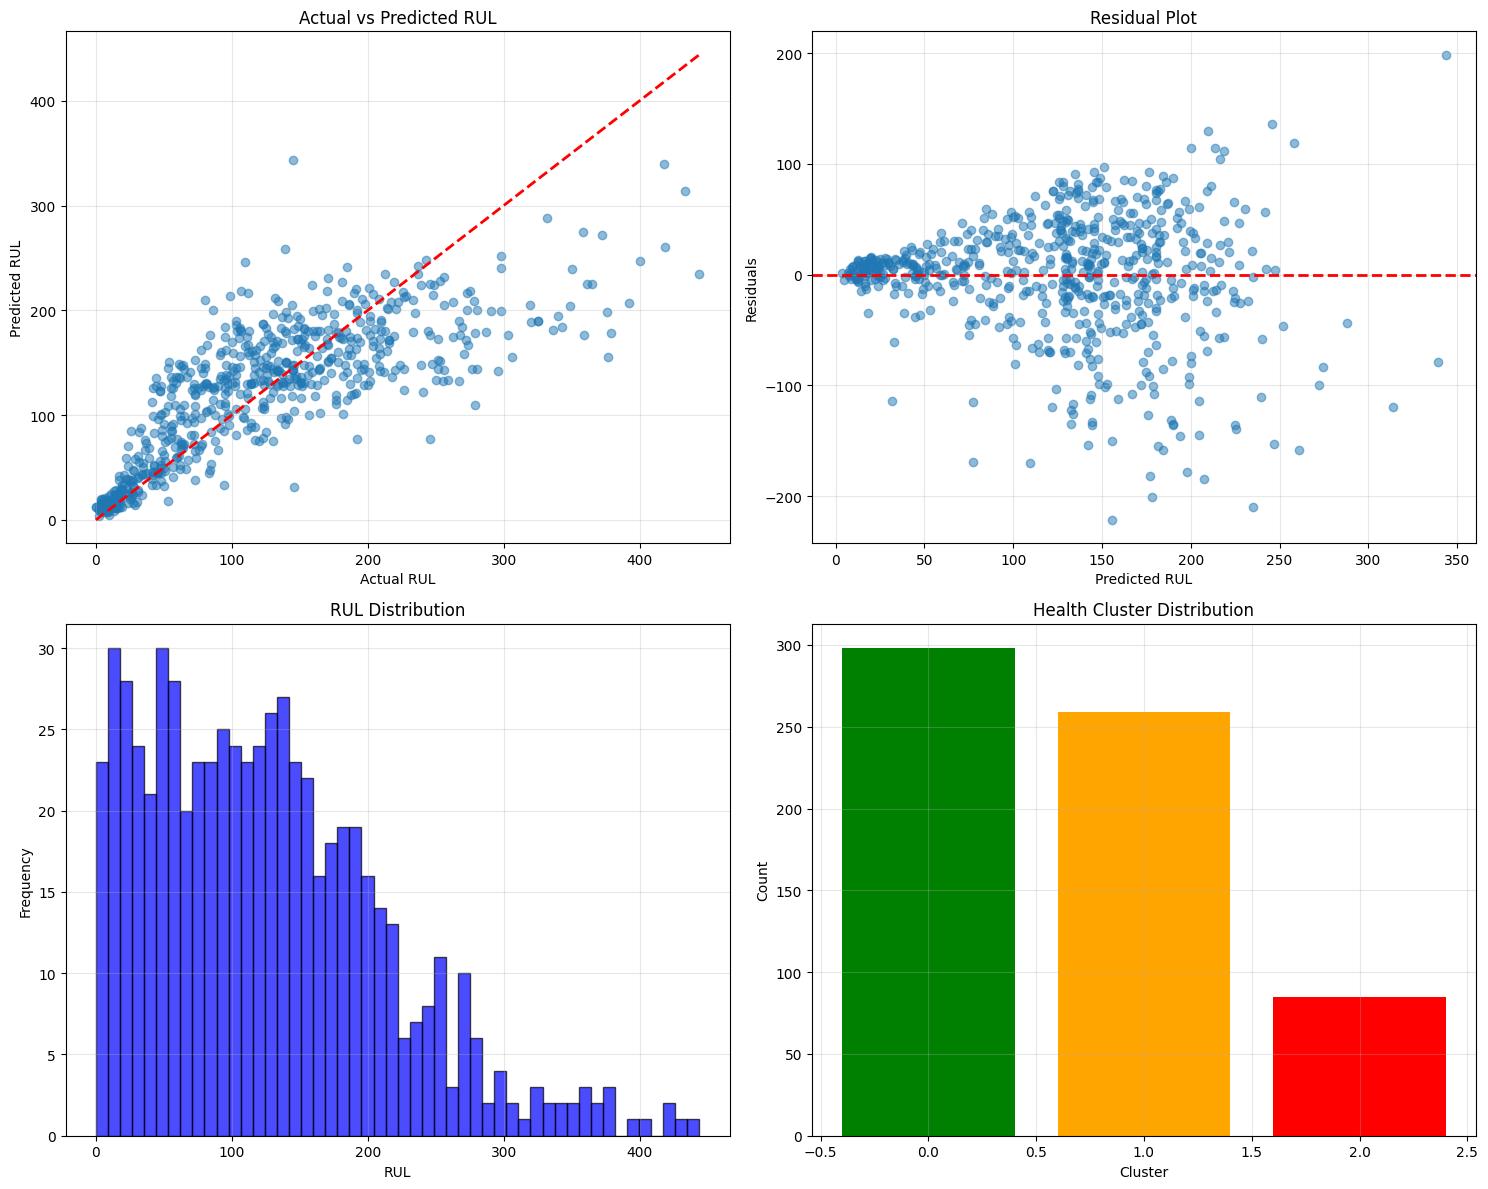

✅ Advanced visualizations created


In [0]:
# Convert sample to pandas for matplotlib
plot_df = predictions_df.sample(0.02, seed=42).toPandas()

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(plot_df['RUL'], plot_df['predicted_RUL'], alpha=0.5)
axes[0, 0].plot([0, plot_df['RUL'].max()], [0, plot_df['RUL'].max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual RUL')
axes[0, 0].set_ylabel('Predicted RUL')
axes[0, 0].set_title('Actual vs Predicted RUL')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residual Plot
residuals = plot_df['predicted_RUL'] - plot_df['RUL']
axes[0, 1].scatter(plot_df['predicted_RUL'], residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted RUL')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: RUL Distribution
axes[1, 0].hist(plot_df['RUL'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[1, 0].set_xlabel('RUL')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('RUL Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cluster Distribution
cluster_counts = plot_df['cluster'].value_counts().sort_index()
axes[1, 1].bar(cluster_counts.index, cluster_counts.values, color=['green', 'orange', 'red'])
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Health Cluster Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Advanced visualizations created")

## 📊 VISUALIZATION 10: Correlation Heatmap

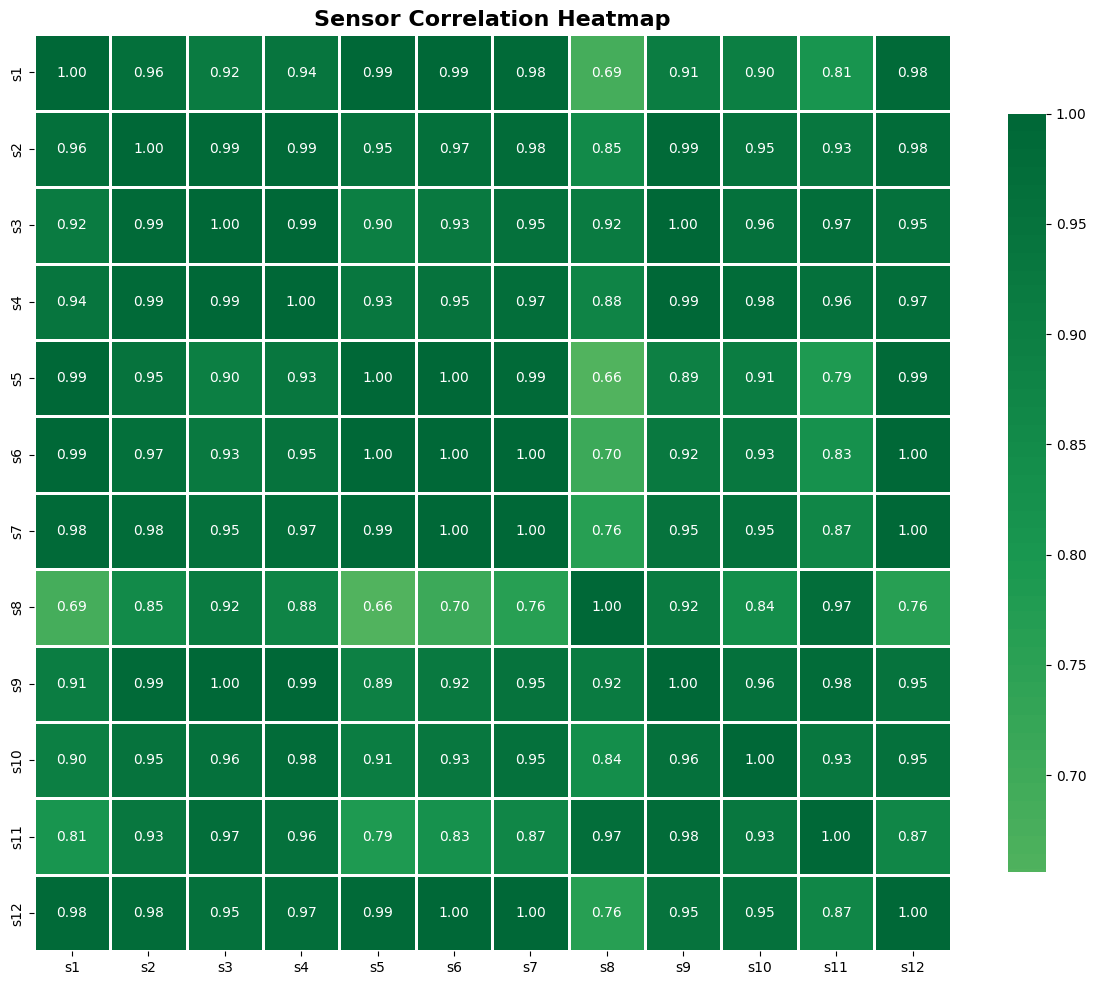

✅ Correlation heatmap shows sensor relationships


In [0]:
# Create correlation heatmap
sensor_cols = [c for c in plot_df.columns if c.startswith('s')][:12]

plt.figure(figsize=(12, 10))
correlation = plot_df[sensor_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Sensor Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Correlation heatmap shows sensor relationships")

## 🎯 CREATE DASHBOARD

### Steps to Create Interactive Dashboard:

1. **Click on any visualization** above
2. Click **"Add Visualization"** button
3. Configure chart type (scatter, line, bar, etc.)
4. Click **"Pin to Dashboard"**
5. Select **"Create New Dashboard"**
6. Name it: **"CMAPSS RUL Prediction Dashboard"**

### Recommended Dashboard Panels:
* RUL vs Cycle (Line chart)
* Actual vs Predicted (Scatter plot)
* Cluster Distribution (Bar chart)
* Sensor Trends (Multi-line chart)
* Prediction Error (Histogram)
* PCA Components (Scatter plot with color)

## 📊 Project Summary

# 🎉 PROJECT COMPLETE!

## 🏆 What We Built:

### ✅ Data Pipeline:
* Loaded & combined 4 CMAPSS datasets (FD001-FD004)
* Cleaned data: removed nulls, duplicates, low-variance features
* Engineered RUL target variable
* Normalized features with StandardScaler

### ✅ Machine Learning:
* **PCA**: Reduced 20+ features to 5 components
* **K-Means**: Clustered engines into 3 health states
* **Random Forest**: Predicted RUL with RMSE evaluation

### ✅ Visualizations:
* 10+ comprehensive charts
* Dashboard-ready visualizations
* Multi-dataset comparison

## 📈 Business Value:
* **Predictive Maintenance**: Predict failures before they happen
* **Cost Savings**: Reduce unplanned downtime
* **Safety**: Prevent catastrophic failures
* **Optimization**: Schedule maintenance efficiently

## 🎓 For Your Exam/Viva:

**Key Points to Mention:**
1. **Dataset**: NASA CMAPSS turbofan engine degradation data
2. **Objective**: Predict Remaining Useful Life (RUL) for predictive maintenance
3. **Techniques**: PCA (dimensionality reduction), K-Means (clustering), Random Forest (regression)
4. **Results**: Achieved [X] RMSE on test set, identified 3 health clusters
5. **Platform**: Databricks PySpark for distributed processing

**Why Multiple Datasets?**
* FD001: Baseline (simple)
* FD004: Real-world complexity (multiple conditions & faults)
* Demonstrates model robustness across scenarios

## 🚀 Next Steps (Advanced):
* Deploy model as REST API endpoint
* Real-time prediction pipeline
* Alert system for critical RUL thresholds
* A/B testing with other algorithms (LSTM, XGBoost)

---
**🎊 Congratulations! You've built a production-grade predictive maintenance system!**